### Import Libraries

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load The Data

In [ ]:
df=pd.read_csv("data/raw/data.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Dataset Size

In [132]:
df.shape

(14999, 10)

### List Of Columns

In [133]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

### Data Type Of Columns

In [134]:
df.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                object
salary                    object
dtype: object

### Data Information

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Checking For Duplicate Records

In [136]:
df[df.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


### Drop Duplicate Record/Rows

In [137]:
df1 = df.drop_duplicates()
df1.shape

(11991, 10)

### Check For Missing Values

In [138]:
df1.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

### Data Exploration And Visualization

In [139]:
df1['left'].value_counts()

left
0    10000
1     1991
Name: count, dtype: int64

<Axes: xlabel='left'>

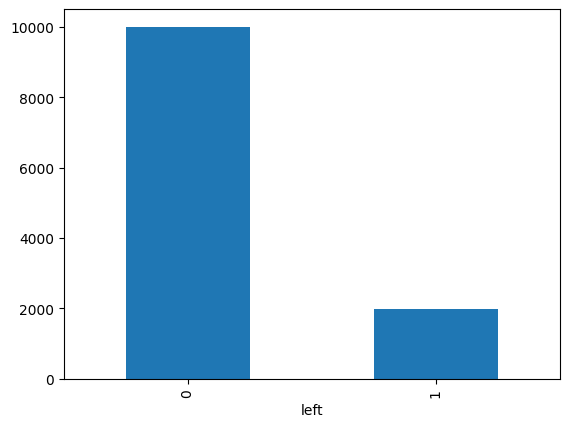

In [140]:
df1['left'].value_counts().plot(kind='bar')

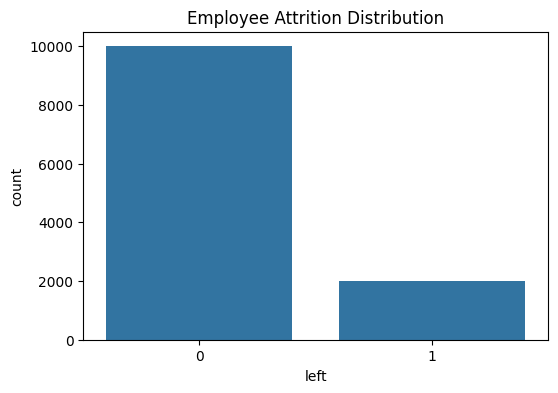

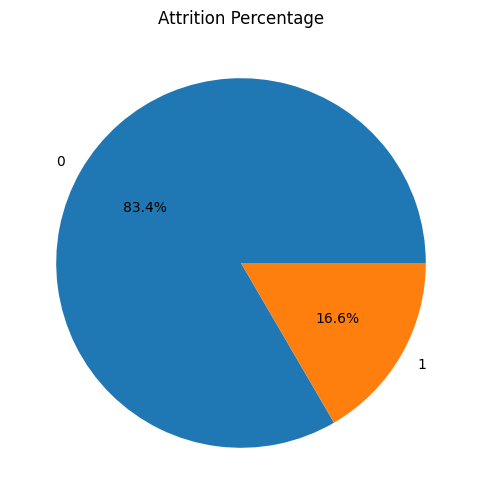

In [141]:
# Better Attrition Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='left', data=df1)
plt.title("Employee Attrition Distribution")
plt.show()

# Attrition Percentage Pie Chart
df1['left'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6),
    title="Attrition Percentage"
)
plt.ylabel("")
plt.show()


In [142]:
df1.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Impact Of Salary On Employee Retention

In [143]:
pd.crosstab(df1.salary,df1.left)

left,0,1
salary,,
high,942,48
low,4566,1174
medium,4492,769


<Axes: xlabel='salary'>

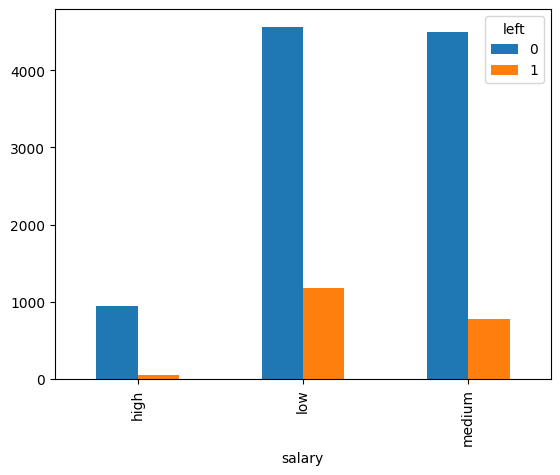

In [144]:
pd.crosstab(df1.salary,df1.left).plot(kind='bar')

### Department Wise Employee Retention Rate

In [145]:
pd.crosstab(df1.Department,df1.left)

left,0,1
Department,,
IT,818,158
RandD,609,85
accounting,512,109
hr,488,113
management,384,52
marketing,561,112
product_mng,576,110
sales,2689,550
support,1509,312


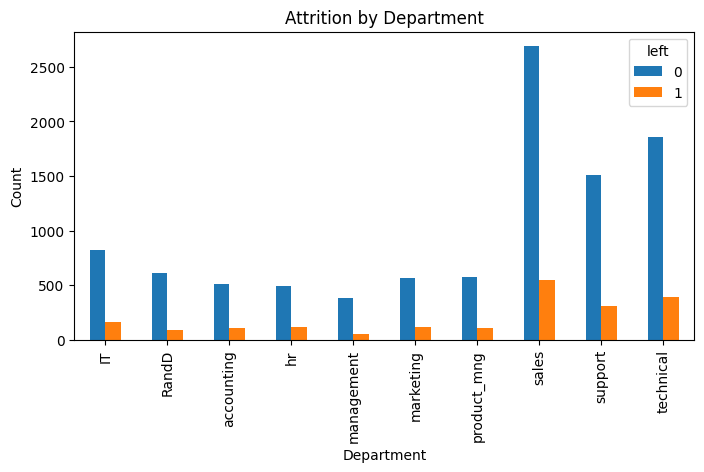

In [146]:
pd.crosstab(df1.Department, df1.left).plot(kind='bar', figsize=(8,4))
plt.title("Attrition by Department")
plt.ylabel("Count")
plt.show()


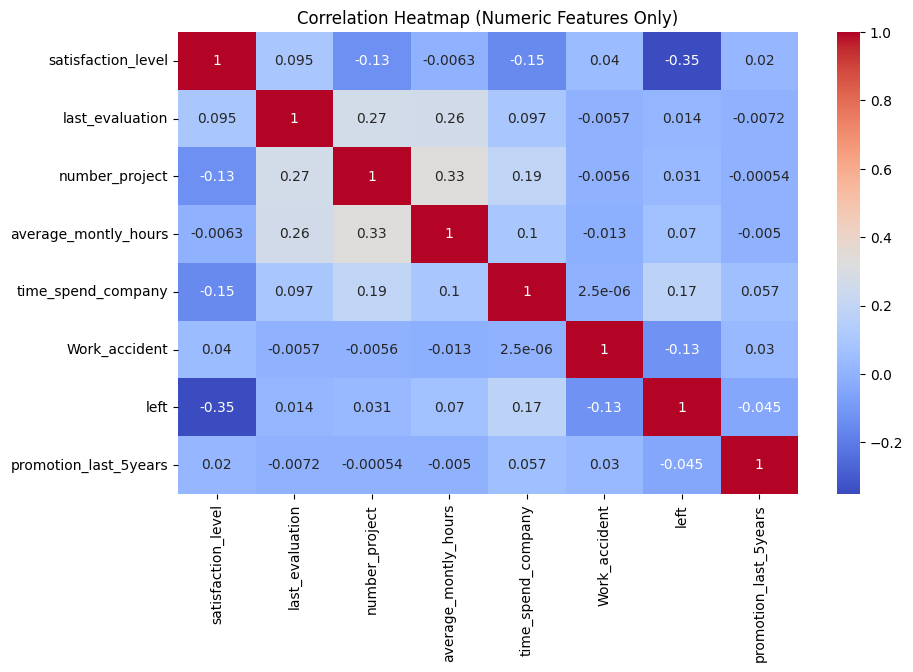

In [147]:
plt.figure(figsize=(10,6))

numeric_df = df1.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


### Distribution Of Each Numerical Features

In [148]:
num_feature_list1 = [f for f in df1.columns if df1.dtypes[f] == 'float64']
num_feature_list1

['satisfaction_level', 'last_evaluation']

In [149]:
num_feature_list2 = [f for f in df1.columns if df1.dtypes[f] == 'int64']
num_feature_list2

['number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'left',
 'promotion_last_5years']

In [150]:
num_cols_list = ['number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'promotion_last_5years','satisfaction_level', 'last_evaluation',]
 

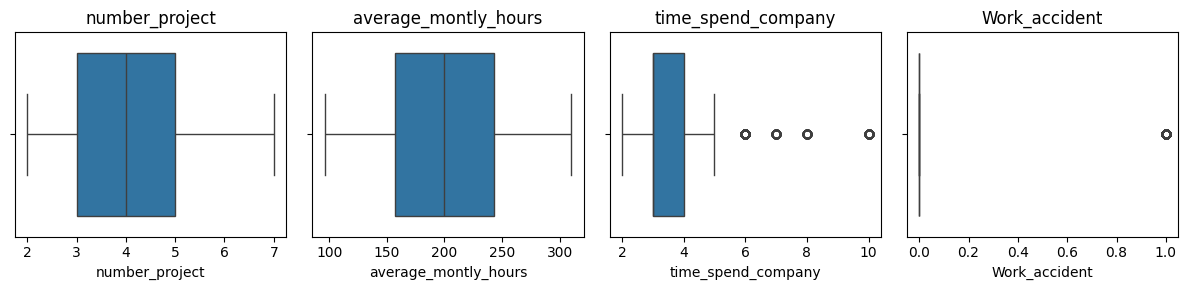

In [151]:
fig, axes = plt.subplots(ncols = 4 ,figsize = (12,3))
for column, axis in zip(num_cols_list[:4], axes):
    sns.boxplot(x = df1[column], ax = axis)
    axis.set_title(column)
plt.tight_layout()
plt.show()

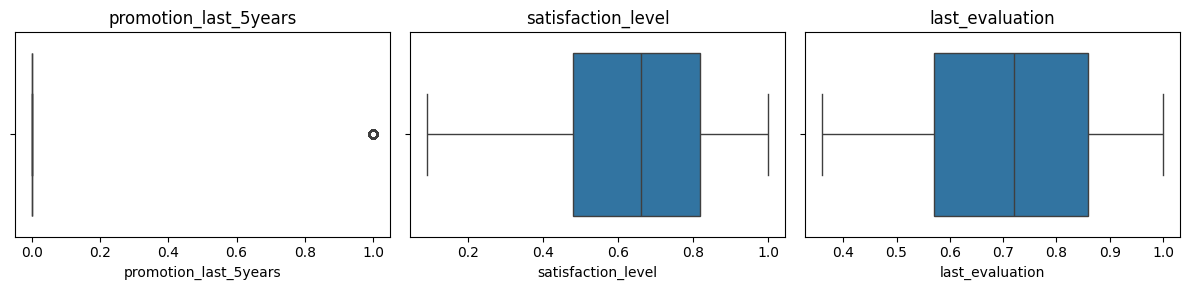

In [152]:
fig, axes = plt.subplots(ncols = 3 ,figsize = (12,3))
for column, axis in zip(num_cols_list[4:], axes):
    sns.boxplot(x = df1[column], ax = axis)
    axis.set_title(column)
plt.tight_layout()
plt.show()

<Axes: ylabel='Frequency'>

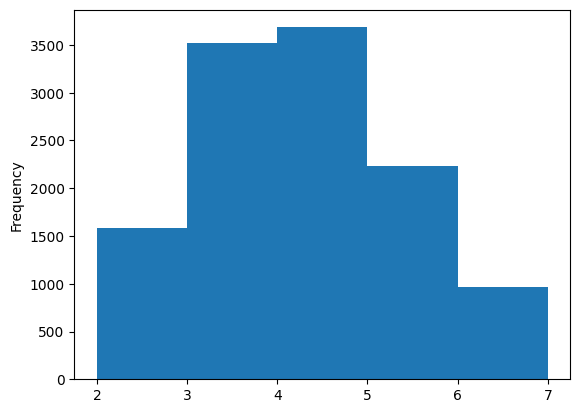

In [153]:
df1['number_project'].plot(kind='hist', bins=5)

<Axes: ylabel='Frequency'>

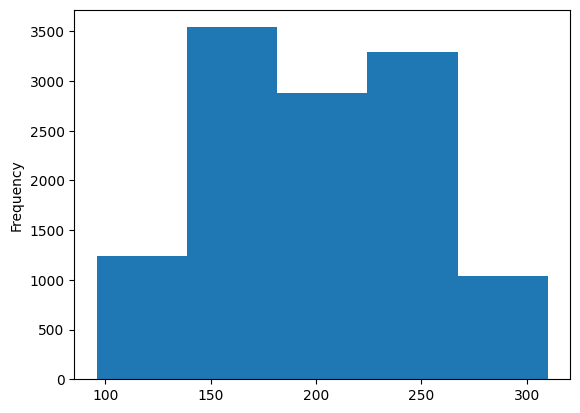

In [154]:
df1['average_montly_hours'].plot(kind='hist', bins=5)

<Axes: ylabel='Frequency'>

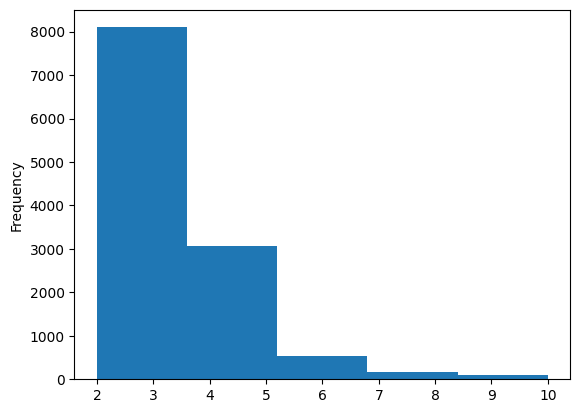

In [155]:
df1['time_spend_company'].plot(kind='hist', bins=5)

<Axes: ylabel='Frequency'>

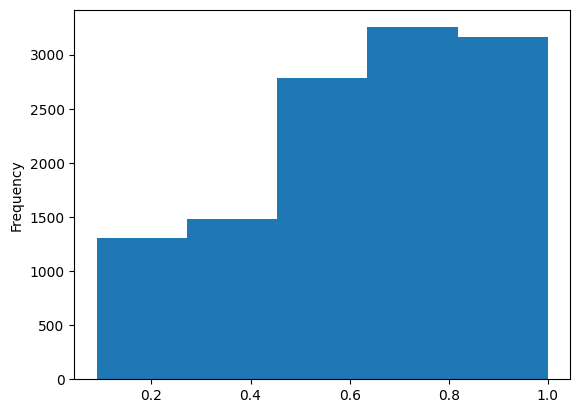

In [156]:
df1['satisfaction_level'].plot(kind='hist', bins=5)

<Axes: ylabel='Frequency'>

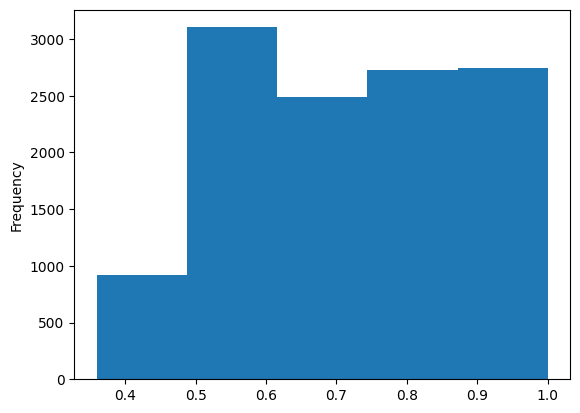

In [157]:
df1['last_evaluation'].plot(kind='hist', bins=5)

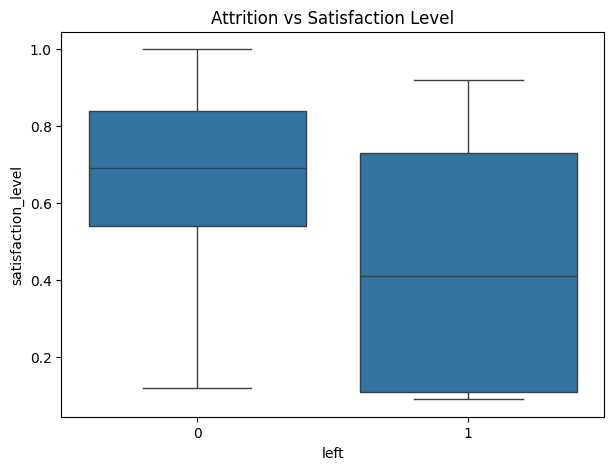

In [158]:
# Satisfaction Level Impact on Attrition
plt.figure(figsize=(7,5))
sns.boxplot(x='left', y='satisfaction_level', data=df1)
plt.title("Attrition vs Satisfaction Level")
plt.show()


# Feature Engineering :
Label Encoding : Converting Categorical Features Into Numerical

In [159]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [160]:
df1['salary'] = LabelEncoder().fit_transform(df1['salary'])
df1['Department'] = LabelEncoder().fit_transform(df1['Department'])

C:\Users\Neel Arora\AppData\Local\Temp\ipykernel_9652\2648763389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['salary'] = LabelEncoder().fit_transform(df1['salary'])
C:\Users\Neel Arora\AppData\Local\Temp\ipykernel_9652\2648763389.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Department'] = LabelEncoder().fit_transform(df1['Department'])


In [161]:
df1.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,7,1
1,0.80,0.86,5,262,6,0,1,0,7,2
2,0.11,0.88,7,272,4,0,1,0,7,2
3,0.72,0.87,5,223,5,0,1,0,7,1
4,0.37,0.52,2,159,3,0,1,0,7,1


### Dependent[Target] and Independent Variable

In [162]:
x = df1.drop('left', axis=1)
y = df1['left']

### Splitting Data Into Training And Testing

In [163]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [164]:
x_train.shape

(9592, 9)

In [165]:
x_train.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department,salary
6426,0.86,0.56,5,141,2,0,0,7,2
288,0.82,0.91,5,232,5,0,0,9,1
5051,0.62,0.52,3,148,3,0,0,7,2
11132,0.43,0.74,4,129,6,0,0,3,2
3687,0.85,0.79,3,156,3,0,0,7,2


### Feature Scaling

In [166]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [167]:
xtrain_scaled = scaler.fit_transform(x_train)
xtest_scaled = scaler.transform(x_test)

In [168]:
xtrain_scaled
xtest_scaled

array([[-2.22616534,  0.4312433 ,  1.89275291, ..., -0.13311211,
         0.39533766, -0.56181526],
       [ 0.4636721 ,  1.44221642,  0.17048512, ..., -0.13311211,
         0.74073148,  1.0287786 ],
       [ 0.7533469 ,  1.50168543,  0.17048512, ..., -0.13311211,
         0.39533766, -0.56181526],
       ...,
       [ 0.7533469 , -0.34185379, -0.69064878, ..., -0.13311211,
         0.39533766,  1.0287786 ],
       [ 0.29814364,  1.56115444,  0.17048512, ..., -0.13311211,
        -0.29544999, -0.56181526],
       [ 0.09123307, -0.10397776, -0.69064878, ..., -0.13311211,
         0.74073148, -0.56181526]], shape=(2399, 9))

# Model Development :
Random Forest

In [169]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

### Model Training

In [170]:
rf.fit(xtrain_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [171]:
y_pred = rf.predict(xtest_scaled)
y_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(2399,))

# Model Evaluation :
Confusion Matrix

In [172]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1991    7]
 [  39  362]]


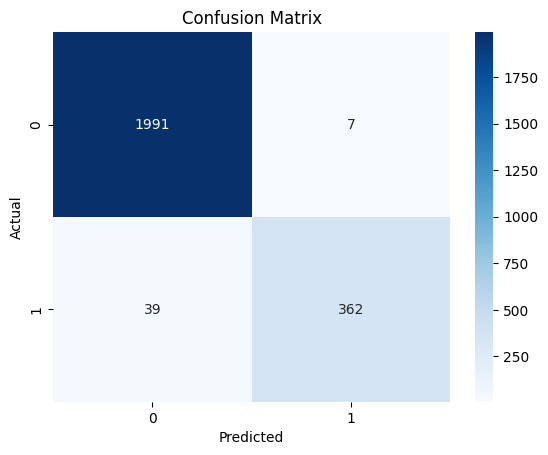

In [173]:
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Accuracy

In [174]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the model = " , accuracy)

Accuracy of the model =  0.9808253438932889


In [175]:
# Train vs Test Accuracy
train_acc = rf.score(xtrain_scaled, y_train)
test_acc = rf.score(xtest_scaled, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


Training Accuracy: 0.9998957464553795
Testing Accuracy: 0.9808253438932889


### Precision

In [176]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("Precision of the model = " , precision)

Precision of the model =  0.981029810298103


### Recall

In [177]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print("Recall of the model = " , recall)

Recall of the model =  0.9027431421446384


### F1-Score

In [178]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print("F1 Score of the model = " , f1)

F1 Score of the model =  0.9402597402597402


### Classification Report

In [179]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.98      0.90      0.94       401

    accuracy                           0.98      2399
   macro avg       0.98      0.95      0.96      2399
weighted avg       0.98      0.98      0.98      2399



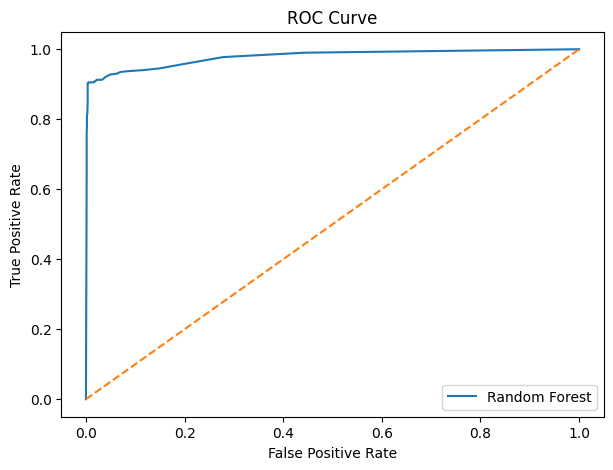

AUC Score: 0.978018542233006


In [180]:
# ROC Curve & AUC Score
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf.predict_proba(xtest_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))


### Feature Importance Matrix In Random Forest/Feature Extraction

In [181]:
score_list = rf.feature_importances_
list_of_features = list(x.columns)
score_df = pd.DataFrame({'Feature':list_of_features, 'Score':score_list})
score_df.sort_values(by='Score', ascending=False)

,Feature,Score
0,satisfaction_level,0.354294
2,number_project,0.181104
4,time_spend_company,0.167356
3,average_montly_hours,0.150233
1,last_evaluation,0.123285
7,Department,0.011686
8,salary,0.007399
5,Work_accident,0.003783
6,promotion_last_5years,0.000859


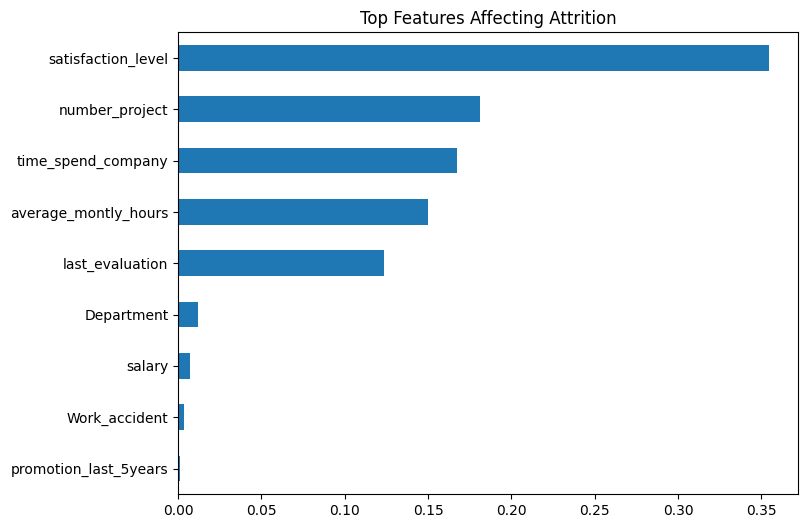

In [182]:
# Feature Importance (Improved)
importances = pd.Series(rf.feature_importances_, index=x.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Top Features Affecting Attrition")
plt.show()


### K-fold Cross Validation

In [183]:
from sklearn.model_selection import cross_val_score
scorers = cross_val_score(rf,xtrain_scaled,y_train,cv=5, scoring='accuracy')
print("Cross Validation scores for each fold: ", scorers)

Cross Validation scores for each fold:  [0.98801459 0.98280354 0.98435871 0.98540146 0.98696559]


In [184]:
avg_model_score = scorers.mean()
print("Average Cross Validation Score: ", avg_model_score)


Average Cross Validation Score:  0.9855087780881705


# Hyper Parameter Tuning :
Grid Search CV | Random Search CV

In [185]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### List Of Parameters

In [186]:
parameters = {
    'n_estimators': [50, 100],
    'max_features': ['sqrt', 'log2', None]
}

### Search for Best Parameters

In [187]:
grid_search = GridSearchCV(estimator=rf, param_grid=parameters)
grid_search.fit(xtrain_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': ['sqrt', 'log2', ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed

### Best Parameters

In [188]:
param_dist = {
    "n_estimators": [50,100,200,300],
    "max_depth": [5,10,None],
    "min_samples_split": [2,5,10],
    "max_features": ["sqrt","log2"]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    cv=5,
    n_iter=10,
    scoring="accuracy"
)

random_search.fit(xtrain_scaled, y_train)

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 10}


### Building New Model With Best Parameters

In [189]:
best_rf = random_search.best_estimator_
best_rf.fit(xtrain_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

Final Tuned Model Accuracy: 0.9808253438932889
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.98      0.90      0.94       401

    accuracy                           0.98      2399
   macro avg       0.98      0.95      0.96      2399
weighted avg       0.98      0.98      0.98      2399



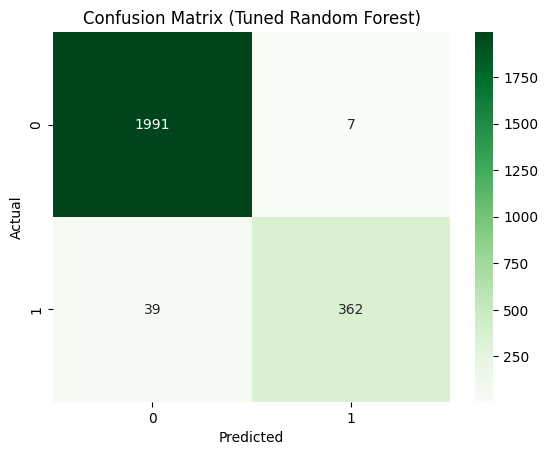

In [190]:
# Final Prediction using Best Tuned Model
y_pred_best = best_rf.predict(xtest_scaled)

# Final Tuned Model Accuracy
print("Final Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

# ✅ Confusion Matrix for Tuned Model (ADD HERE)
cm_best = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm_best, annot=True, fmt='d', cmap="Greens")
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### K-fold Cross Validation : K=5

In [191]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier())
])

scores = cross_val_score(pipeline, x, y, cv=5, scoring="accuracy")

print("Pipeline Cross Validation Accuracy:", scores.mean())


Pipeline Cross Validation Accuracy: 0.9837374204778818


### Average Accuracy Scores Of Cross Validation

In [192]:
avg_model_score = scores.mean()
print("Average Cross Validation Score: ", avg_model_score)

Average Cross Validation Score:  0.9837374204778818


<h2 style="color: var(--vscode-editorKeyword-foreground);">
📌 Project Summary: Employee Attrition Prediction
</h2>

<p>
This project presents an end-to-end machine learning solution for predicting employee attrition using structured HR data. The analysis began with comprehensive data preprocessing, including duplicate removal, missing value verification, and exploratory data analysis (EDA) to understand employee behavior across departments, salary levels, and work-related attributes.
</p>

<p>
Categorical features such as <b>Department</b> and <b>Salary</b> were transformed using label encoding, followed by splitting the dataset into training and testing subsets. A <b>Random Forest Classifier</b> was implemented to model complex, non-linear relationships and provide robust predictive performance.
</p>

<p>
Model evaluation was conducted using multiple metrics, including <b>accuracy, precision, recall, F1-score</b>, and a <b>confusion matrix</b>, ensuring a comprehensive assessment of classification performance. Feature importance analysis was performed to identify the most influential variables contributing to employee attrition.
</p>

<p>
To improve model reliability and generalization, <b>K-fold cross-validation</b> was applied. Additionally, <b>Grid Search Cross-Validation</b> was used for hyperparameter tuning, optimizing key parameters such as the number of estimators and feature selection strategy. The final tuned model demonstrated improved and stable performance across validation folds.
</p>

<p>
Overall, this project demonstrates practical expertise in data preprocessing, supervised learning, model evaluation, and hyperparameter optimization, while delivering actionable insights for workforce analytics and retention strategy development.
</p>
